# Visualización y informes

Todo lo que un run produce vive en su directorio (`.soma/runs/<run_id>/`);
todo lo de este notebook son *lectores* de esos ficheros. Tres capas:
lectores/agregación (Rust, `RunView`), overlays sobre el grafo
(mermaid/graphviz anotados) y figuras Plotly (`soma.viz`, extra
`pip install 'somatize[viz]'`).

In [1]:
import json, pathlib

import plotly.io as pio

import soma

# PNG estático (kaleido): las figuras se ven en cualquier visor, GitHub
# incluido. Para interactividad (zoom/hover), comenta esta línea y abre
# el notebook en Jupyter/VS Code.
pio.renderers.default = "png"
pio.renderers["png"].scale = 2      # nítido en pantallas retina
pio.renderers["png"].width = 950
from soma import Filter, Graph, Study, search


class Scaler(Filter):
    _cache_version = "nb07-scaler-v1"

    def fit(self, x, y=None):
        return {"mean": sum(x) / len(x)}

    def forward(self, x, state):
        return [v - state["mean"] for v in x]


class Model(Filter):
    _cache_version = "nb07-model-v1"

    def fit(self, x, y=None):
        return {"w": 0.5}

    def forward(self, x, state):
        return [v * state["w"] for v in x]


g = Graph()
g.node("scaler", Scaler())
g.node("model", Model())
g.connect("scaler", "model")

with g.track_run("nb07-fit", kind="fit", tags=["demo"]) as run:
    g.fit([1.0, 2.0, 3.0, 4.0])
    for step in range(6):
        run.log("loss", 1.0 / (step + 1), step=step)
        run.log("val_f1", 0.6 + 0.06 * step, step=step)

run.id

'run_20260730T113248_441a'

## Listar e inspeccionar runs

`soma.runs()` escanea `<root>/runs/` (más reciente primero). Un run
`running` con heartbeat caducado se reporta como `crashed`. Cada
`RunView` agrega el log de eventos en formas listas para graficar.

In [2]:
runs = soma.runs()   # RunList: en notebook se renderiza como tabla
view = runs[0]
runs

run id,kind,state,created,duration,name
run_20260730T113248_441a,fit,completed,2026-07-30 11:32:48,0.0s,nb07-fit


In [3]:
import pandas as pd

print("caché:", view.cache_activity())
pd.DataFrame(view.node_timings())   # spans por nodo, listos para tabla

caché: {'hits': 0, 'misses': 0, 'by_node': {}}


,node_id,started_ts,finished_ts,duration_ms,outcome,cache_tier,error
0,scaler,2026-07-30T11:32:48.641450990Z,2026-07-30T11:32:48.642173719Z,0,completed,None,None
1,model,2026-07-30T11:32:48.642222634Z,2026-07-30T11:32:48.642765444Z,0,completed,None,None


## Arquitectura anotada

El grafo del run con su overlay: duración por nodo, hits de caché y
flags de salud, coloreado por estado. `view.to_svg()` es un SVG
autocontenido (también existen `to_mermaid()` y `to_graphviz()` para
docs y herramientas externas).

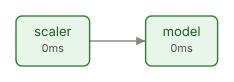

In [4]:
from IPython.display import SVG

SVG(view.to_svg())   # mismo overlay disponible en to_mermaid()/to_graphviz()

## Figuras

Métodos instalados sobre `RunView`; devuelven figuras Plotly
interactivas (requieren el extra `somatize[viz]`).

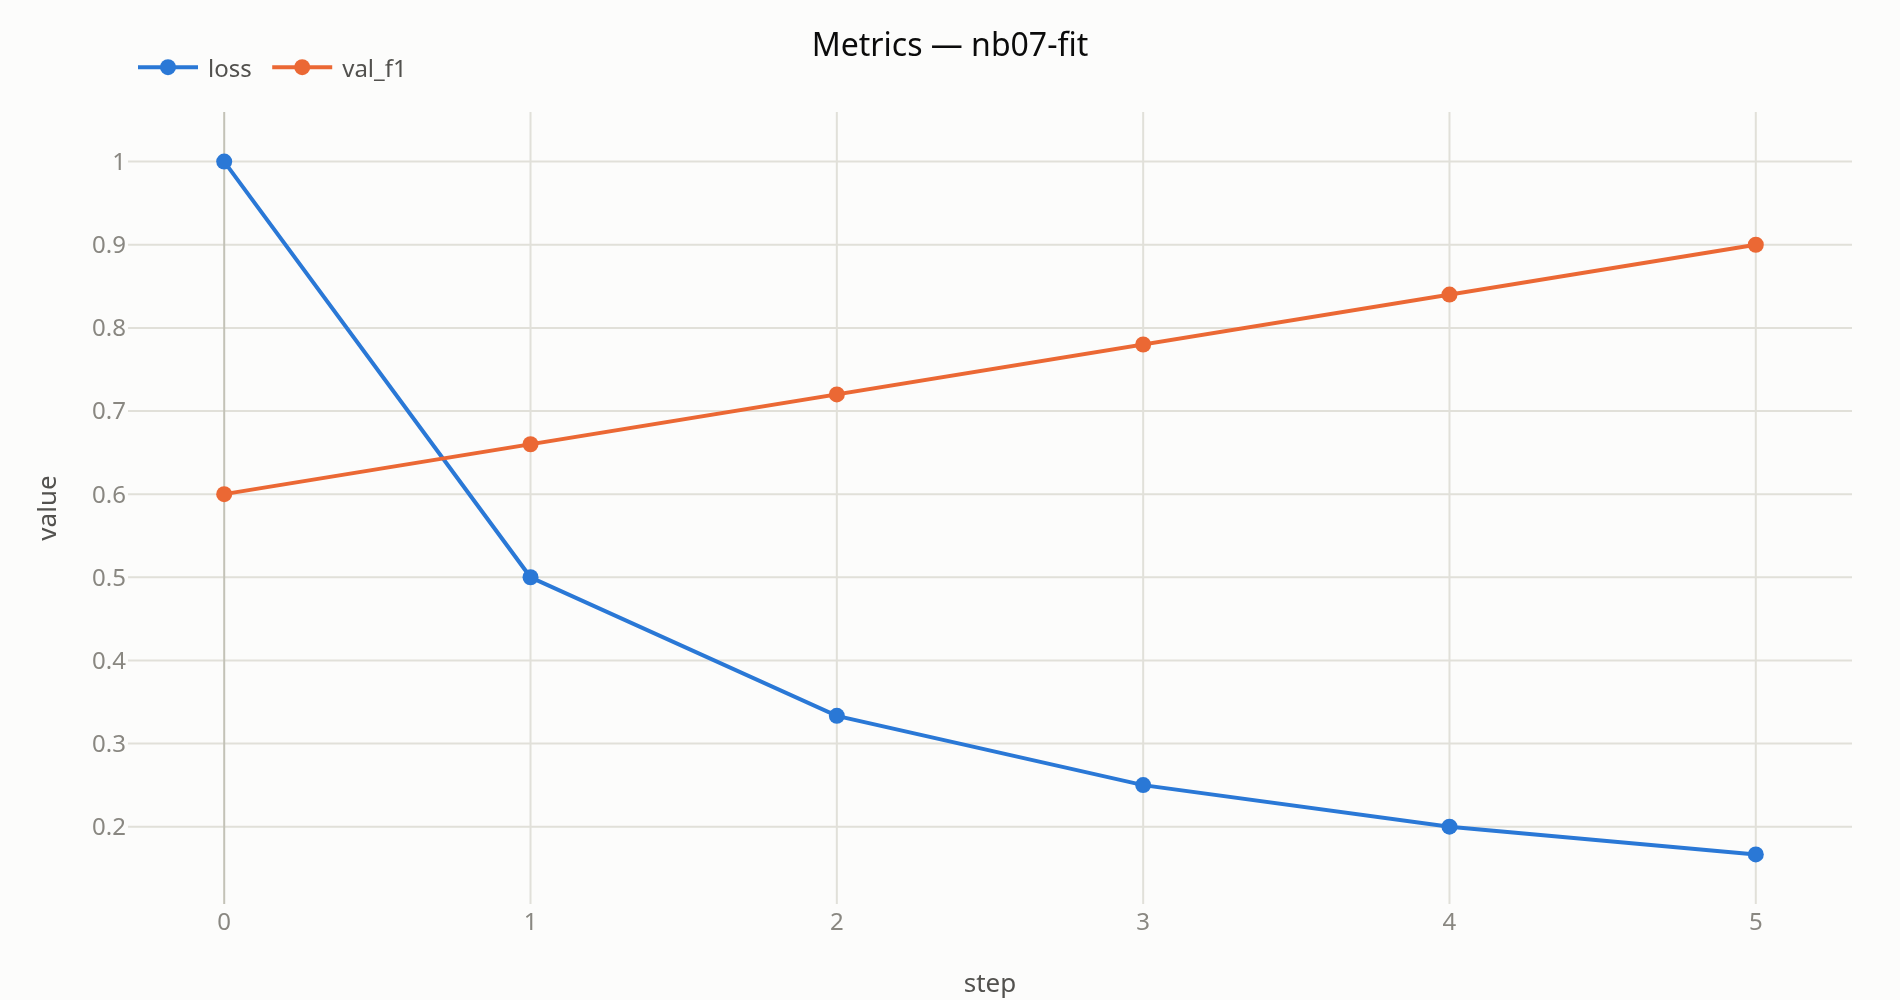

In [5]:
view.plot_metrics()

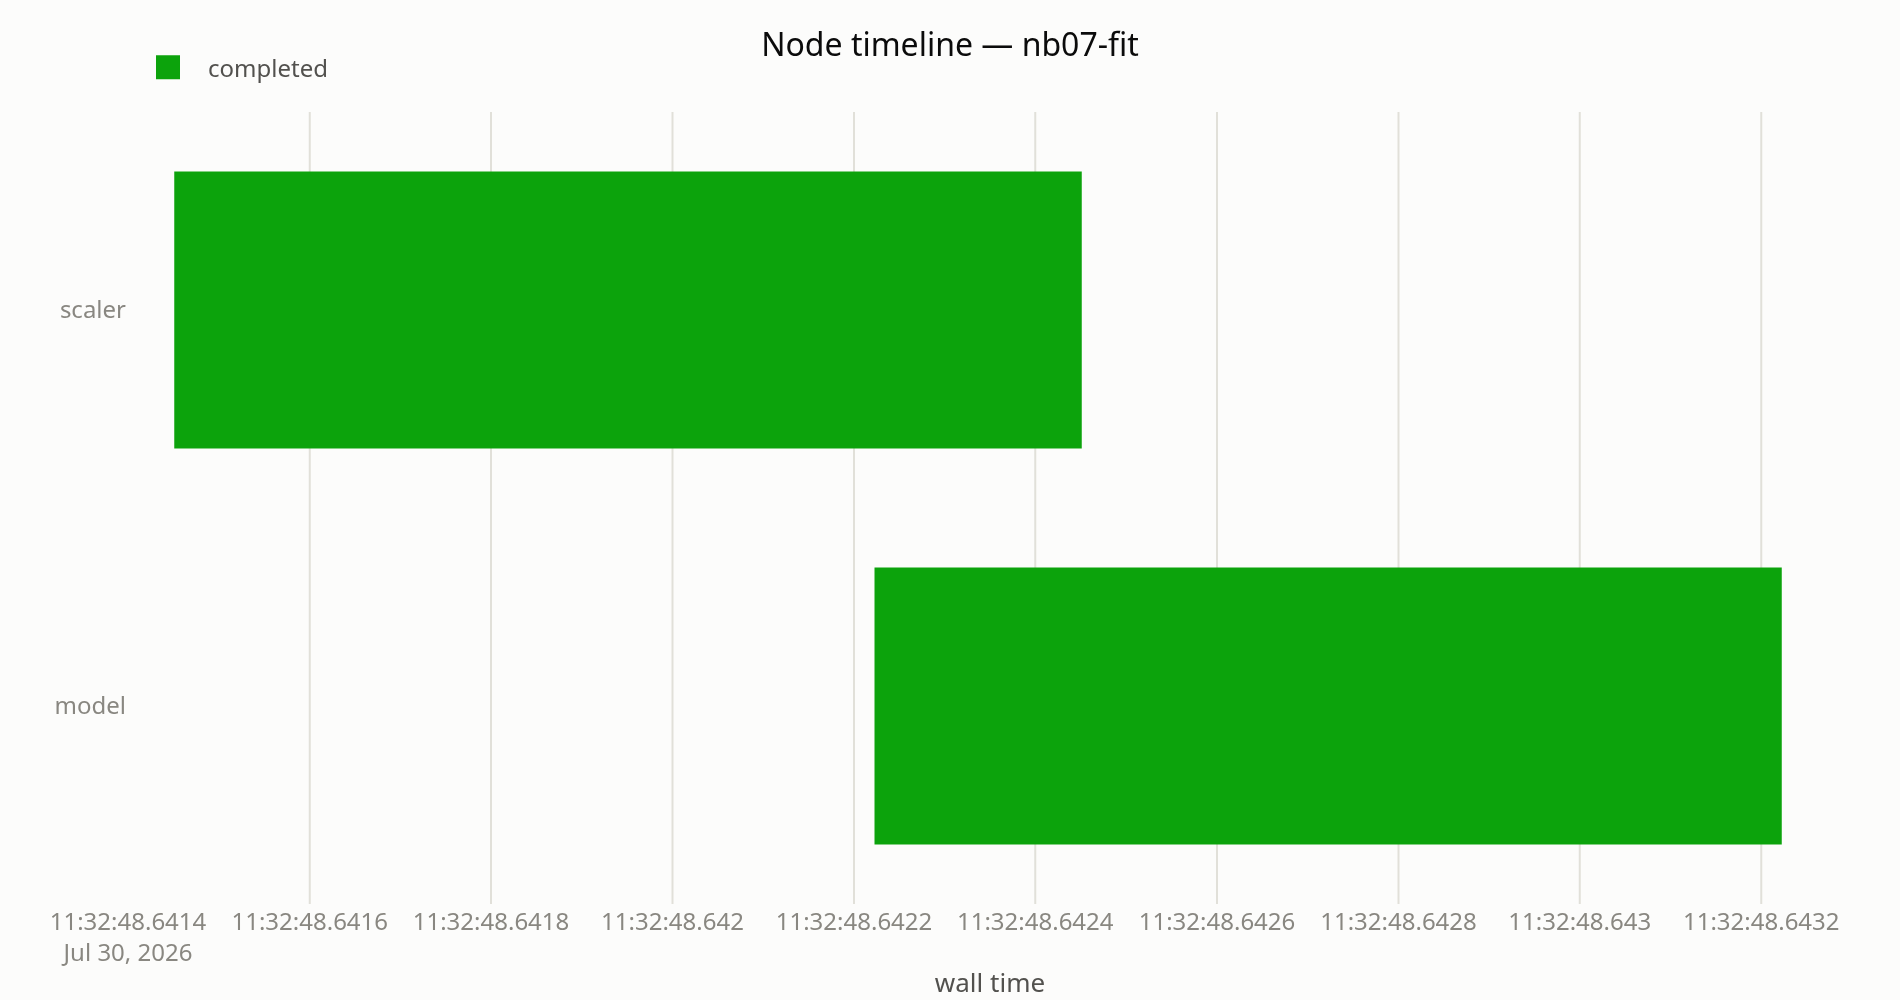

In [6]:
view.plot_gantt()  # dónde se fue el tiempo de pared, nodo a nodo

## Optimización estilo Optuna

Un `Study` es también un run (su run-dir tiene `study.json`); las
figuras llevan los nombres de Optuna para no sorprender a nadie. En una
terminal, `study.run(objective, progress=True)` pinta además una barra
de progreso tqdm con el mejor valor como sufijo (extra `somatize[viz]`).

In [7]:
def objective(trial):
    for step in range(5):
        f1 = 0.5 + 0.35 * trial["lr"] ** 0.2 * (step + 1) / 5
        if trial.report("f1", f1, step):
            return None
    return None


study = Study(
    "nb07-hpo",
    search_space=[
        {"type": "float", "name": "lr", "low": 1e-4, "high": 1e-1, "scale": "log"},
        {"type": "float", "name": "dropout", "low": 0.0, "high": 0.5},
    ],
    strategy="bayesian",
    n_trials=8,
    objectives=[("f1", "maximize")],
    pruning=("median", 2),
    seed=42,
)
study.run(objective, progress=True)
study.best_trial["id"], study.best_trial["metrics"]

nb07-hpo:   0%|          | 0/8 [00:00<?, ?trial/s]

nb07-hpo: 100%|██████████| 8/8 [00:00<00:00, 165292.77trial/s]

nb07-hpo: 100%|██████████| 8/8 [00:00<00:00, 5246.98trial/s]  

('trial_0006', {'f1': 0.6971705694400159})

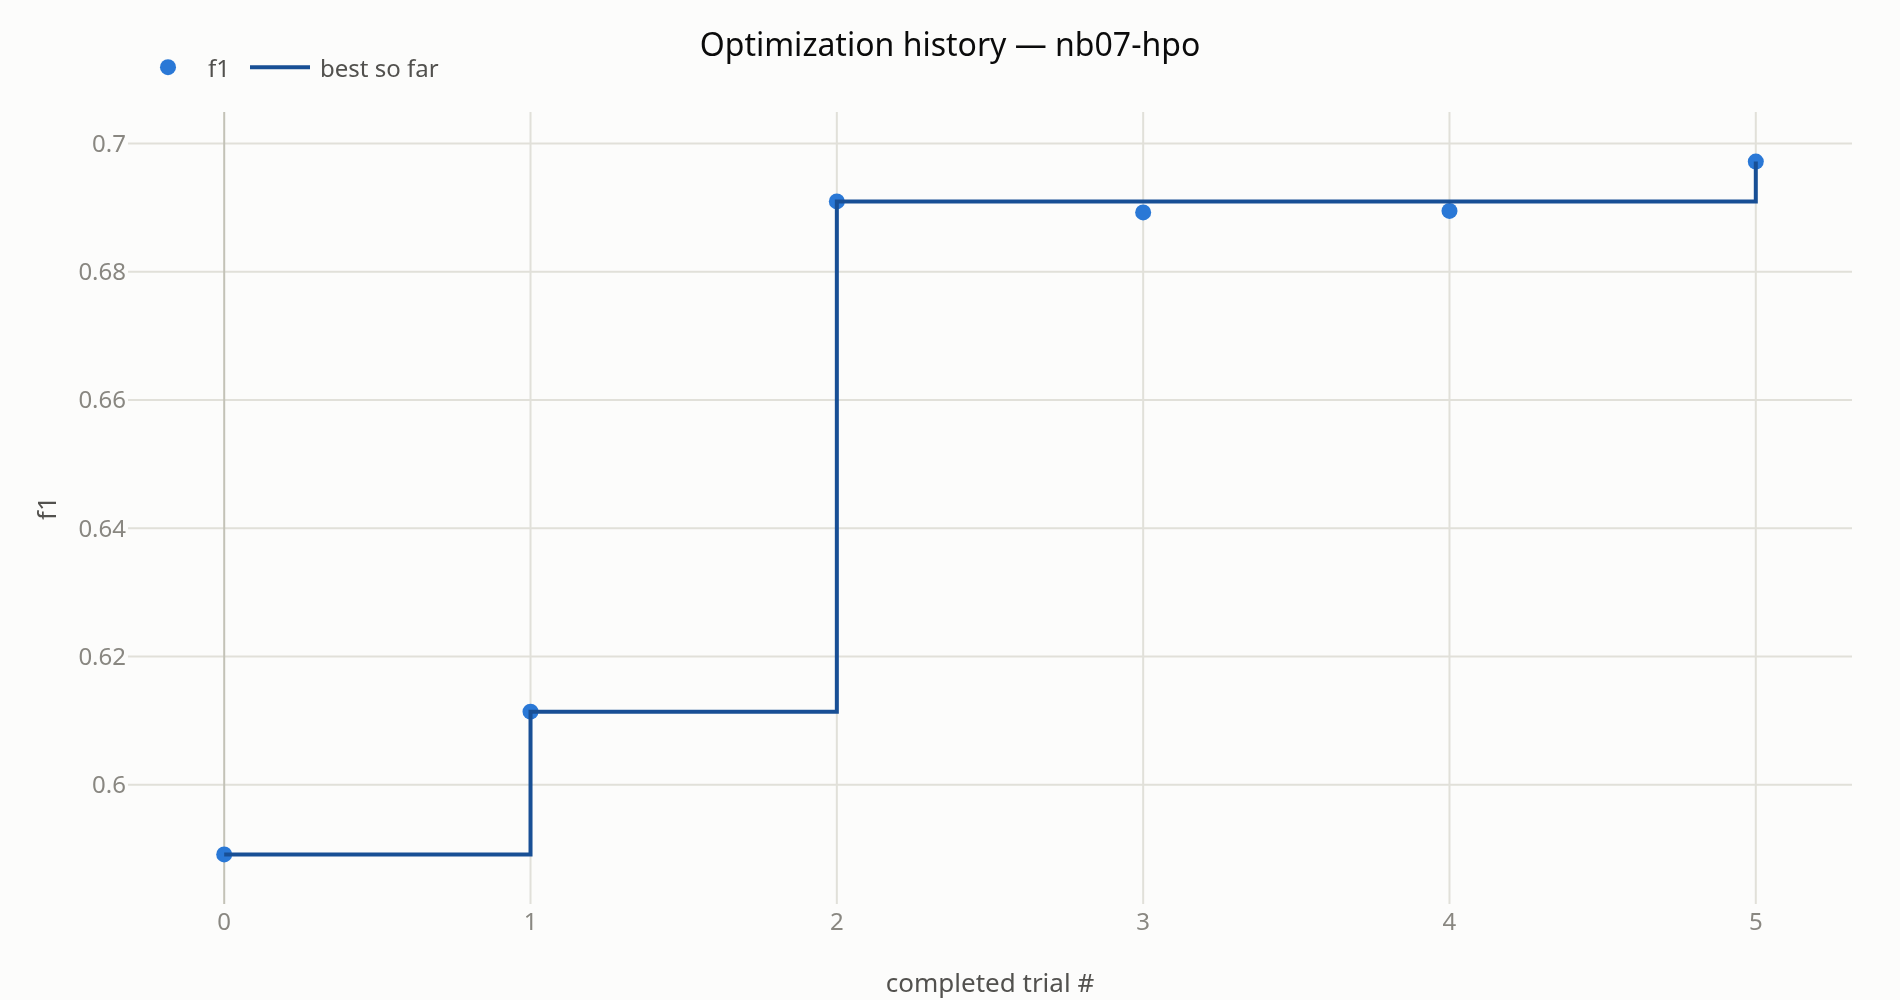

In [8]:
study.plot_optimization_history()

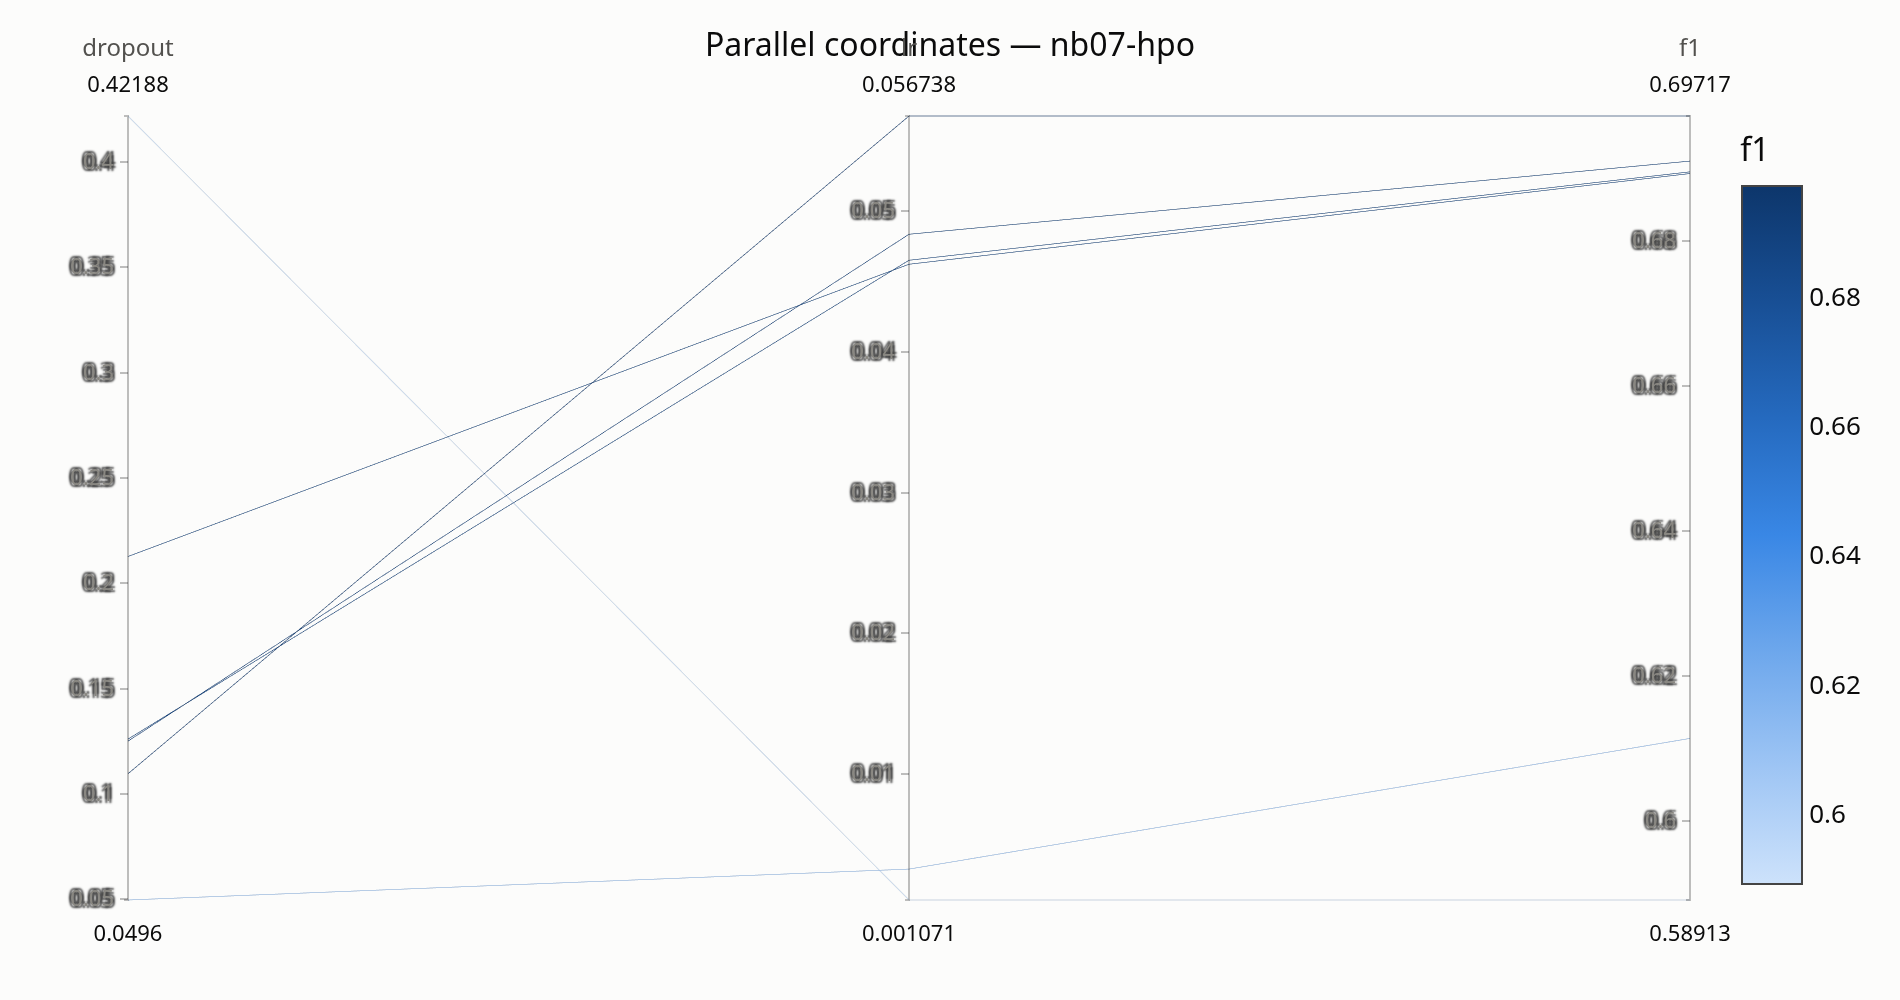

In [9]:
study.plot_parallel_coordinate()

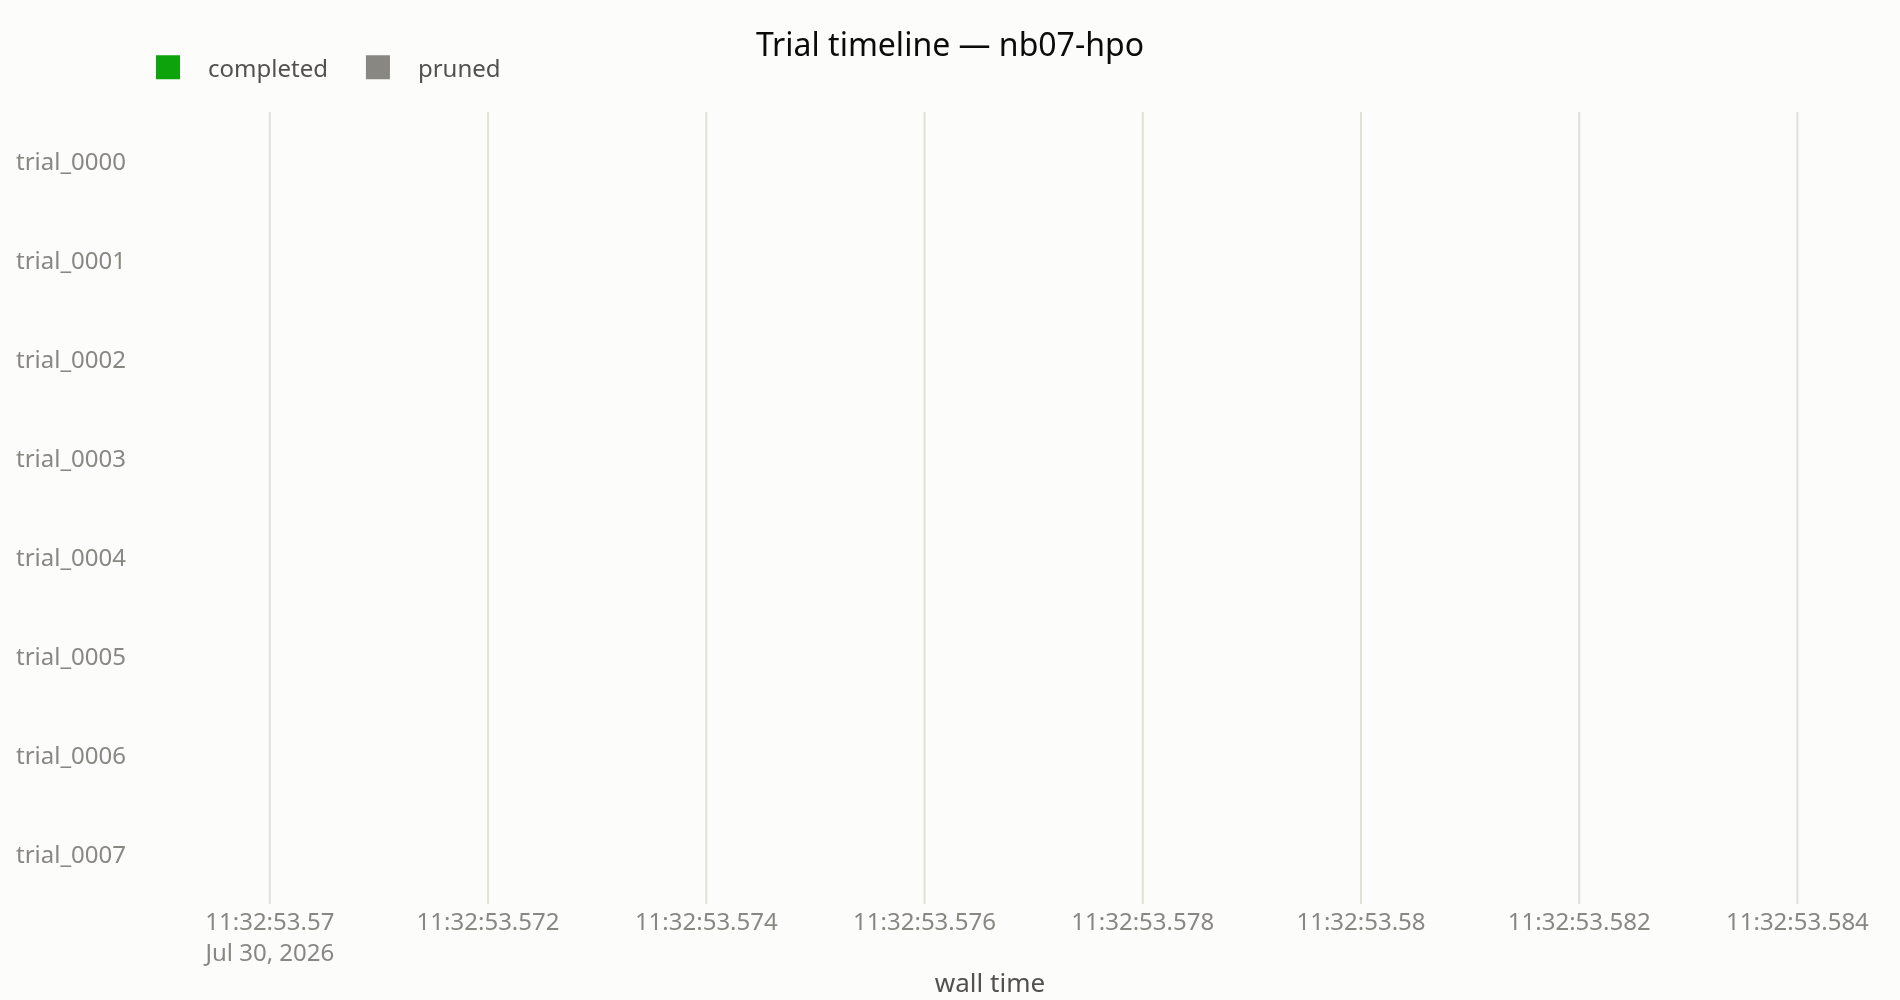

In [10]:
study.plot_timeline()

In [11]:
study.trials_dataframe().head()

,trial_id,state,started_at,finished_at,duration_ms,param_lr,param_dropout,metric_f1
0,trial_0000,completed,2026-07-30 11:32:53.569530031+00:00,2026-07-30 11:32:53.570570960+00:00,0,0.001071,0.421878,0.589134
1,trial_0001,completed,2026-07-30 11:32:53.571339354+00:00,2026-07-30 11:32:53.572308022+00:00,0,0.003266,0.049605,0.611397
2,trial_0002,completed,2026-07-30 11:32:53.573274588+00:00,2026-07-30 11:32:53.574246612+00:00,0,0.048341,0.125046,0.690955
3,trial_0003,pruned,2026-07-30 11:32:53.575424457+00:00,2026-07-30 11:32:53.576050573+00:00,0,0.000259,0.303276,0.540271
4,trial_0004,completed,2026-07-30 11:32:53.577099440+00:00,2026-07-30 11:32:53.577831499+00:00,0,0.046212,0.212712,0.689243


## Informe HTML

Un fichero autocontenido por run: DAG anotado, tiles de eficiencia,
curvas, sección HPO con tabla de trials y sección de salud. Desde la
CLI: `soma report <run_id>` (`--inline` embebe plotly.js para verlo sin
red). Los blobs `<script id="soma-data-*">` embebidos son el contrato
que leerá la futura GUI.

In [12]:
html = study.to_html(path="nb07_report.html")
print(f"nb07_report.html: {len(html) / 1024:.0f} KiB")
print("secciones:", [s.split("</h2>")[0] for s in html.split("<h2>")[1:]])

nb07_report.html: 30 KiB
secciones: ['Efficiency', 'Metrics', 'Optimization', 'Trials', 'Health']
